In [2]:
from os.path import exists, join
from os import makedirs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ctf_dataset.load import create_wrapped_dataset

In [3]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")

In [4]:
matchup_id = 0
n_maps = 32
n_repeats = 32

team_pairs = {0: {'coop': 0, 'comp': [1, 2]},
              1: {'coop': 0, 'comp': [3, 4]},
              2: {'coop': 5, 'comp': [1, 3]},
              3: {'coop': 5, 'comp': [2, 4]}}

In [5]:
# Convenience function for computing root mean square (RMS)
def rms(a, axis=None):
    return np.sqrt(np.nanmean(a ** 2, axis=axis))

In [33]:
# Function to sample same-size non-overlapping segments of non-behavior
def resample_nonbehavior(behavior, n_resample=1000, exclude=None, 
                         max_iters=int(1e6)):
    n_players, n_samples = 4, 4501
    
    off_behavior = np.full((n_players, n_samples, n_resample), False)
    for player_id in np.arange(4):
        
        if np.sum(behavior[player_id]) == 0:
            off_samples = np.full((n_samples, n_resample), False)
            
        else:
            ons = np.where(behavior[player_id])[0]
            offs = np.where(~behavior[player_id])[0]
            
            # Pad one False onto the end to ensure np.diff catches last time point
            behavior_pad = np.concatenate((np.array([False])[:, np.newaxis],
                                           behavior[player_id],
                                           np.array([False])[:, np.newaxis]),
                                          axis=0)

            bounds = np.where(np.diff(behavior_pad, axis=0))[0]
            bounds_split = np.split(bounds, bounds.shape[0] // 2)
            durs = [offset - onset for onset, offset in bounds_split]

            off_samples = []
            for n in np.arange(n_resample):
                ### Do not require non-overlapping with on behaviors
                invalid_samples = [] #ons.copy().tolist()
                
                if exclude is not None:
                    invalid_samples.extend(np.where(exclude[player_id, :, 0])[0])
                    orig_invalid = invalid_samples.copy()
                    invalid_samples = sorted(invalid_samples)
                    
                off_sample = []
                for dur in durs:
                    valid_sample = False
                    tries = 0
                    while not valid_sample:
                        onset = np.random.choice(offs)
                        sample = onset + np.arange(dur)
                        if not np.any(np.in1d(sample, invalid_samples)) and not np.any(sample >= n_samples):
                            invalid_samples.extend(sample)
                            valid_sample = True
                        else:
                            valid_sample = False
                            tries += 1
                            if (tries > max_iters and
                                    not np.any(np.in1d(sample, orig_invalid)) and
                                    not np.any(sample >= n_samples)):
                                #print(f"Failed to find a valid event after {max_iters} tries—skipping!")
                                valid_sample = True
                                break
                            #print('Overlap with behavior! Resampling...')
                            #print(sample)
                    off_sample.extend(sample)

                off_bool = np.full(n_samples, False)
                off_bool[off_sample] = True
                off_samples.append(off_bool)

            off_samples = np.column_stack(off_samples)

        off_behavior[player_id] = off_samples

    return off_behavior

In [7]:
from behavior_heuristics import (following_teammate, escort,
                                 cycling, spawn_camping,
                                 mobbing, assist)

behavior_names = {'follow': following_teammate, 'escort': escort,
                  'cycle': cycling, 'camp': spawn_camping,
                  'mob': mobbing, 'assist': assist}

In [32]:
map_id, repeat_id = slice(None), 0 #slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)

behaviors = {}
for b in behavior_names:
    behavior = behavior_names[b](
        wrap_f, map_id=map_id, matchup_id=matchup_id,
        repeat_id=repeat_id, player_id=player_id)
    behaviors[b] = behavior
    print(f"{b} frequency: {np.sum(behavior) / behavior.size:.3f}")

follow frequency: 0.019
escort frequency: 0.013
cycle frequency: 0.092
camp frequency: 0.100
mob frequency: 0.019
assist frequency: 0.031


In [ ]:
n_resample = 1000
n_maps = 32
n_repeats = 0

behavior_name = 'camp'
behavior = behaviors[behavior_name][:, np.newaxis]

on_values, off_values = [], []
for map_id in np.arange(n_maps):
    for repeat_id in [0]: #np.arange(n_repeats):
        
        is_alive = wrap_f['map/matchup/repeat/player/time/is_alive'][
            map_id, matchup_id, repeat_id]
        teammate_alive = wrap_f['map/matchup/repeat/player/time/teammate_is_alive'][
            map_id, matchup_id, repeat_id]
        both_alive = np.all(np.stack((is_alive, teammate_alive), axis=0), axis=0)
        
        value = wrap_f['map/matchup/repeat/player/time/value'][
            map_id, matchup_id, repeat_id].astype(np.float32)

        on_value = value.copy()
        np.place(on_value, ~behavior[map_id, repeat_id], np.nan)
        on_mean = np.nanmean(on_value)
        on_values.append(on_mean)
        
        off_behavior = resample_nonbehavior(behavior[map_id, repeat_id],
                                            n_resample=n_resample,
                                            exclude=~both_alive)
        np.save(f'results/{behavior_name}-off_matchup-{matchup_id}_'
                f'map-{map_id}_repeat-{repeat_id}_bool.npy', off_behavior)
        
        off_value = np.repeat(value, n_resample, axis=2)
        np.place(off_value, ~off_behavior, np.nan)
        off_mean = np.nanmean(off_value, axis=(0, 1))
        off_values.append(off_mean)
        
        print(f"Finished resampling {behavior_name} non-behavior for map {map_id} {repeat_id}")

on_values = np.stack(on_values, axis=0)
off_values = np.stack(off_values, axis=0)
    
np.save(f'results/value_{behavior_name}-on_matchup-{matchup_id}_results.npy', on_values)
np.save(f'results/value_{behavior_name}-off_matchup-{matchup_id}_results.npy', off_values)
    
on_df = {'map': [], 'repeat': [], 'behavior': [], 'value': []}
for map_id in np.arange(n_maps):
    for repeat_id in [0]: #np.arange(n_repeats):
        on_df['map'].append(map_id)
        on_df['repeat'].append(repeat_id)
        on_df['behavior'].append(behavior_name)
        #on_df['value'].append(on_values[map_id * n_maps + repeat_id])
        on_df['value'].append(on_values[map_id])
on_df = pd.DataFrame(on_df)
on_df.to_csv(f'results/value_{behavior_name}-on_matchup-{matchup_id}_results.csv', index=False)

off_values_mean = np.nanmean(off_values, axis=0)
off_df = {'resample': [], 'behavior': [], 'value': []}
for resample_id in np.arange(n_resample):
    off_df['resample'].append(resample_id)
    off_df['behavior'].append(behavior_name)
    off_df['value'].append(off_values_mean[resample_id])
off_df = pd.DataFrame(off_df)
off_df.to_csv(f'results/value_{behavior_name}-off_matchup-{matchup_id}_results.csv', index=False)

Finished resampling camp non-behavior for map 0 0
Finished resampling camp non-behavior for map 1 0
Finished resampling camp non-behavior for map 2 0
Finished resampling camp non-behavior for map 3 0
Finished resampling camp non-behavior for map 4 0
Finished resampling camp non-behavior for map 5 0
Finished resampling camp non-behavior for map 6 0
Finished resampling camp non-behavior for map 7 0
Finished resampling camp non-behavior for map 8 0
Finished resampling camp non-behavior for map 9 0


In [ ]:
behavior_name = 'camp'
on_df = pd.read_csv(f'results/value_{behavior_name}-on_matchup-{matchup_id}_results.csv')
off_df = pd.read_csv(f'results/value_{behavior_name}-off_matchup-{matchup_id}_results.csv')

fig, ax = plt.subplots(figsize=(6, 3))
sns.pointplot(x='value', y='behavior', data=on_df, ax=ax, color='darkgoldenrod')
sns.stripplot(x='value', y='behavior', data=off_df, ax=ax, color='.5', alpha=.2)
sns.despine()

In [351]:
# Load in following behavior
from behavior_heuristics import following_teammate
behavior_name = 'following'

map_id, repeat_id = slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)
min_behavior_length = 15
teammate_radius = 7
following_angle = 90
leading_angle = 90

behavior = following_teammate(wrap_f, map_id=map_id, matchup_id=matchup_id,
    repeat_id=repeat_id, player_id=player_id, min_behavior_length=min_behavior_length, 
    teammate_radius=teammate_radius, following_angle=following_angle, leading_angle=leading_angle)

print(f"{behavior_name} frequency: {np.sum(behavior) / behavior.size:.3f}")

/mnt/cup/labs/hasson/snastase/social-ctf/behavior_heuristics.py:425: RuntimeWarning: invalid value encountered in true_divide
  np.linalg.norm(player_velocity[..., :2], axis=-1))))[..., np.newaxis]
/mnt/cup/labs/hasson/snastase/social-ctf/behavior_heuristics.py:425: RuntimeWarning: invalid value encountered in arccos
  np.linalg.norm(player_velocity[..., :2], axis=-1))))[..., np.newaxis]
/mnt/cup/labs/hasson/snastase/social-ctf/behavior_heuristics.py:431: RuntimeWarning: invalid value encountered in true_divide
  np.linalg.norm(teammate_velocity[..., :2], axis=-1))))[..., np.newaxis]
/mnt/cup/labs/hasson/snastase/social-ctf/behavior_heuristics.py:431: RuntimeWarning: invalid value encountered in arccos
  np.linalg.norm(teammate_velocity[..., :2], axis=-1))))[..., np.newaxis]


following frequency: 0.021


In [145]:
# Load in assist behavior
from behavior_heuristics import assist
behavior_name = 'assist'

map_id, repeat_id = slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)
min_behavior_length = 15
min_approach = 0
own_flag_radius = 4

behavior = assist(wrap_f, map_id=map_id, matchup_id=matchup_id,
    repeat_id=repeat_id, player_id=player_id, min_behavior_length=min_behavior_length,
    min_approach=min_approach, own_flag_radius=own_flag_radius)

print(f"{behavior_name} frequency: {np.sum(behavior) / behavior.size:.3f}")

assist frequency: 0.041


In [228]:
# Load in escort behavior
from behavior_heuristics import escort
behavior_name = 'escort'

map_id, repeat_id = slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)
min_behavior_length = 30
teammate_radius = 3

behavior = escort(wrap_f, map_id=map_id, matchup_id=matchup_id,
    repeat_id=repeat_id, player_id=player_id, min_behavior_length=min_behavior_length,
    teammate_radius=teammate_radius)

print(f"{behavior_name} frequency: {np.sum(behavior) / behavior.size:.3f}")

escort frequency: 0.012


In [296]:
# Load in cycling behavior
from behavior_heuristics import cycling
behavior_name = 'cycling'

map_id, repeat_id = slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)
min_behavior_length = 15
teammate_angle = 90
base_angle = 90

behavior = cycling(wrap_f, map_id=map_id, matchup_id=matchup_id,
    repeat_id=repeat_id, player_id=player_id, min_behavior_length=min_behavior_length, 
    teammate_angle=teammate_angle, base_angle=base_angle)

print(f"{behavior_name} frequency: {np.sum(behavior) / behavior.size:.3f}")

cycling frequency: 0.058


In [157]:
# Load in boosting behavior
from behavior_heuristics import boosted_teammate
behavior_name = 'boosted'

n_maps, n_repeats = 32, 32
map_id, repeat_id = slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)

behavior = boosted_teammate(wrap_f, map_id=map_id, matchup_id=matchup_id,
    repeat_id=repeat_id, player_id=player_id)

print(f"{behavior_name} frequency: {np.sum(behavior) / behavior.size:.3f}")
print(f"{np.sum(behavior) / (n_maps * n_repeats):.3f} boosts per game")

boosted frequency: 0.000
3.029 boosts per game


In [320]:
# Load in spawncamping behavior
from behavior_heuristics import spawn_camping
behavior_name = 'spawncamping'

map_id, repeat_id = slice(None), slice(None) # 0, 0
matchup_id, player_id = 0, slice(None)
min_behavior_length = 15
base_radius = 2
flag_base_radius = 2

behavior = spawn_camping(wrap_f, map_id=map_id, matchup_id=matchup_id,
    repeat_id=repeat_id, player_id=player_id, min_behavior_length=min_behavior_length,
    base_radius=base_radius, flag_base_radius=flag_base_radius)

print(f"{behavior_name} frequency: {np.sum(behavior) / behavior.size:.3f}")

spawncamping frequency: 0.020


In [7]:
team_pairs = {0: {'coop': 0, 'comp': [1, 2]},
              1: {'coop': 0, 'comp': [3, 4]},
              2: {'coop': 5, 'comp': [1, 3]},
              3: {'coop': 5, 'comp': [2, 4]}}

In [ ]:
n_resample = 1000
n_pcs = 142

if not exists(f'results/{behavior_name}-on_iscfs'):
    makedirs(f'results/{behavior_name}-on_iscfs')
    makedirs(f'results/{behavior_name}-across_iscfs')
    makedirs(f'results/{behavior_name}-off_iscfs')

on_iscfs, off_iscfs, across_iscfs = [], [], []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        iscfs = np.load(f'results/iscfs_matchup-{matchup_id}_'
                f'map-{map_id}_repeat-{repeat_id}.npy')
        
        on_behavior = behavior[map_id, repeat_id]
        off_behavior = np.load(f'results/{behavior_name}-offov_matchup-{matchup_id}_'
                               f'map-{map_id}_repeat-{repeat_id}_bool.npy')
        
        on_stack, off_stack, across_stack = [], [], []
        for player_id in team_pairs:
            coop_iscf = iscfs[team_pairs[player_id]['coop']]
            on_iscf = coop_iscf[on_behavior[player_id, :, 0]]
            np.save(join(f'results/{behavior_name}-on_iscfs',
                         f'{behavior_name}-on_matchup-{matchup_id}_'
                         f'map-{map_id}_repeat-{repeat_id}_'
                         f'player-{player_id}_iscfs.npy'), on_iscf)
            on_iscf = rms(on_iscf)
            
            comp_iscf = iscfs[team_pairs[player_id]['comp']]
            across_iscf = np.stack([comp_iscf[0, on_behavior[player_id, :, 0]],
                                    comp_iscf[1, on_behavior[player_id, :, 0]]],
                                   axis=0)
            np.save(join(f'results/{behavior_name}-across_iscfs',
                         f'{behavior_name}-across_matchup-{matchup_id}_'
                         f'map-{map_id}_repeat-{repeat_id}_'
                         f'player-{player_id}_iscfs.npy'), across_iscf)
            across_iscf = np.nanmean([rms(across_iscf[0]),
                                      rms(across_iscf[1])])
        
            #off_iscf = []
            #for resample_id in np.arange(n_resample):
            #    off_r = coop_iscf[off_behavior[player_id, :, resample_id]]
                #np.save(join(f'results/{behavior_name}-off_iscfs',
                #         f'{behavior_name}-off_matchup-{matchup_id}_'
                #         f'map-{map_id}_repeat-{repeat_id}_'
                #         f'player-{player_id}_resample-{resample_id}_'
                #         'iscfs.npy'), off_r)
            #    off_iscf.append(rms(off_r))
                
            on_stack.append(on_iscf)
            #off_stack.append(off_iscf)
            across_stack.append(across_iscf)
            
        on_iscfs.append(np.nanmean(on_stack))
        #off_iscfs.append(np.nanmean(off_stack, axis=0))   
        across_iscfs.append(np.nanmean(across_stack))

        print(f"Finished summarizing {behavior_name} ISCF "
              f"for map {map_id}, repeat {repeat_id}")
        
on_iscfs = np.stack(on_iscfs, axis=0)
#off_iscfs = np.stack(off_iscfs, axis=0)
across_iscfs = np.stack(across_iscfs, axis=0)

Finished summarizing following ISCF for map 0, repeat 0
Finished summarizing following ISCF for map 0, repeat 1


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: Mean of empty slice
  This is separate from the ipykernel package so we can avoid doing imports until


Finished summarizing following ISCF for map 0, repeat 2
Finished summarizing following ISCF for map 0, repeat 3
Finished summarizing following ISCF for map 0, repeat 4
Finished summarizing following ISCF for map 0, repeat 5
Finished summarizing following ISCF for map 0, repeat 6
Finished summarizing following ISCF for map 0, repeat 7
Finished summarizing following ISCF for map 0, repeat 8
Finished summarizing following ISCF for map 0, repeat 9
Finished summarizing following ISCF for map 0, repeat 10
Finished summarizing following ISCF for map 0, repeat 11
Finished summarizing following ISCF for map 0, repeat 12
Finished summarizing following ISCF for map 0, repeat 13
Finished summarizing following ISCF for map 0, repeat 14
Finished summarizing following ISCF for map 0, repeat 15
Finished summarizing following ISCF for map 0, repeat 16
Finished summarizing following ISCF for map 0, repeat 17
Finished summarizing following ISCF for map 0, repeat 18
Finished summarizing following ISCF for

In [ ]:
np.save(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_results.npy', on_iscfs)
#np.save(f'results/iscf_{behavior_name}-offov_matchup-{matchup_id}_results.npy', off_iscfs)
np.save(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_results.npy', across_iscfs)
    
on_df = {'map': [], 'repeat': [], 'behavior': [], 'cofluctuation': []}
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        on_df['map'].append(map_id)
        on_df['repeat'].append(repeat_id)
        on_df['behavior'].append(behavior_name)
        on_df['cofluctuation'].append(on_iscfs[map_id * n_maps + repeat_id])
on_df = pd.DataFrame(on_df)
on_df.to_csv(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_results.csv', index=False)

#off_iscfs_mean = np.nanmean(off_iscfs, axis=0)
#off_df = {'resample': [], 'behavior': [], 'cofluctuation': []}
#for resample_id in np.arange(n_resample):
#    off_df['resample'].append(resample_id)
#    off_df['behavior'].append(behavior_name)
#    off_df['cofluctuation'].append(off_iscfs_mean[resample_id])
#off_df = pd.DataFrame(off_df)
#off_df.to_csv(f'results/iscf_{behavior_name}-offov_matchup-{matchup_id}_results.csv', index=False)

#across_df = {'map': [], 'repeat': [], 'behavior': [], 'cofluctuation': []}
#for map_id in np.arange(n_maps):
#    for repeat_id in np.arange(n_repeats):
#        across_df['map'].append(map_id)
#        across_df['repeat'].append(repeat_id)
#        across_df['behavior'].append(behavior_name)
#        across_df['cofluctuation'].append(across_iscfs[map_id * n_maps + repeat_id])
#across_df = pd.DataFrame(across_df)
#across_df.to_csv(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_results.csv', index=False)

In [368]:
behavior_name = 'cycling'

off_iscfs = []
for resample_init in np.arange(10):
    off_r = np.load(f'results/iscf_{behavior_name}-offov_'
                    f'matchup-{matchup_id}_resample-{resample_init}_results.npy')
    off_iscfs.append(off_r)
off_iscfs = np.hstack(off_iscfs)

off_iscfs_mean = np.nanmean(off_iscfs, axis=0)
off_df = {'resample': [], 'behavior': [], 'cofluctuation': []}
for resample_id in np.arange(n_resample):
    off_df['resample'].append(resample_id)
    off_df['behavior'].append(behavior_name)
    off_df['cofluctuation'].append(off_iscfs_mean[resample_id])
off_df = pd.DataFrame(off_df)
off_df.to_csv(f'results/iscf_{behavior_name}-offov_matchup-{matchup_id}_results.csv', index=False)

In [159]:
#repeat_id = 0
#np.save(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_repeat-{repeat_id}_results.npy', on_iscfs)
#np.save(f'results/iscf_{behavior_name}-off_matchup-{matchup_id}_repeat-{repeat_id}_results.npy', off_iscfs)
#np.save(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_repeat-{repeat_id}_results.npy', across_iscfs)

#on_df = {'map': [], 'repeat': [], 'behavior': [], 'cofluctuation': []}
#for map_id in np.arange(n_maps):
#    for repeat_id in [0]:
#        on_df['map'].append(map_id)
#        on_df['repeat'].append(repeat_id)
#        on_df['behavior'].append(behavior_name)
#        on_df['cofluctuation'].append(on_iscfs[map_id])
#on_df = pd.DataFrame(on_df)
#on_df.to_csv(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_repeat-{repeat_id}_results.csv', index=False)

#off_iscfs_mean = np.nanmean(off_iscfs, axis=0)
#off_df = {'resample': [], 'behavior': [], 'cofluctuation': []}
#for resample_id in np.arange(n_resample):
#    off_df['resample'].append(resample_id)
#    off_df['behavior'].append(behavior_name)
#    off_df['cofluctuation'].append(off_iscfs_mean[resample_id])
#off_df = pd.DataFrame(off_df)
#off_df.to_csv(f'results/iscf_{behavior_name}-off_matchup-{matchup_id}_repeat-{repeat_id}_results.csv', index=False)

#across_df = {'map': [], 'repeat': [], 'behavior': [], 'cofluctuation': []}
#for map_id in np.arange(n_maps):
#    for repeat_id in [0]:
#        across_df['map'].append(map_id)
#        across_df['repeat'].append(repeat_id)
#        across_df['behavior'].append(behavior_name)
#        across_df['cofluctuation'].append(across_iscfs[map_id])
#across_df = pd.DataFrame(across_df)
#across_df.to_csv(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_repeat-{repeat_id}_results.csv', index=False)

In [382]:
behavior_name = 'escort'
on_df = pd.read_csv(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_results.csv')
off_df = pd.read_csv(f'results/iscf_{behavior_name}-offov_matchup-{matchup_id}_results.csv')
across_df = pd.read_csv(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_results.csv')

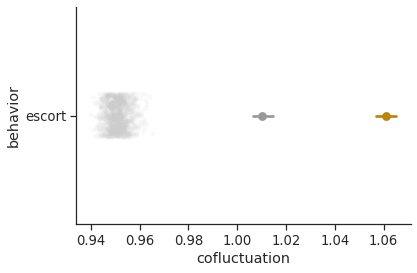

In [383]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(x='cofluctuation', y='behavior', data=on_df, ax=ax, color='darkgoldenrod')
sns.pointplot(x='cofluctuation', y='behavior', data=across_df, ax=ax, color='.6')
sns.stripplot(x='cofluctuation', y='behavior', data=off_df, ax=ax, color='.8', alpha=.1, zorder=0)
sns.despine()

In [362]:
behavior_name = 'following'
on_df = pd.read_csv(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_results.csv')
off_df = pd.read_csv(f'results/iscf_{behavior_name}-off_matchup-{matchup_id}_results.csv')
across_df = pd.read_csv(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_results.csv')

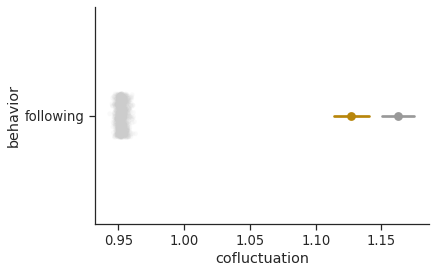

In [363]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(x='cofluctuation', y='behavior', data=on_df, ax=ax, color='darkgoldenrod')
sns.pointplot(x='cofluctuation', y='behavior', data=across_df, ax=ax, color='.6')
sns.stripplot(x='cofluctuation', y='behavior', data=off_df, ax=ax, color='.8', alpha=.1, zorder=0)
sns.despine()

In [313]:
behavior_name = 'following'
repeat_id = 0
on_df = pd.read_csv(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_repeat-{repeat_id}_results.csv')
off_df = pd.read_csv(f'results/iscf_{behavior_name}-off_matchup-{matchup_id}_repeat-{repeat_id}_results.csv')
across_df = pd.read_csv(f'results/iscf_{behavior_name}-across_matchup-{matchup_id}_repeat-{repeat_id}_results.csv')

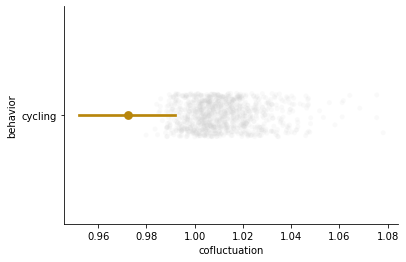

In [185]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(x='cofluctuation', y='behavior', data=on_df, ax=ax, color='darkgoldenrod')
#sns.pointplot(x='cofluctuation', y='behavior', data=across_df, ax=ax, color='.6')
sns.stripplot(x='cofluctuation', y='behavior', data=off_df, ax=ax, color='.8', alpha=.1, zorder=0)
sns.despine()

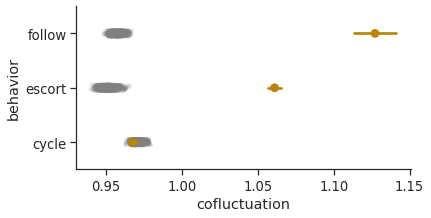

In [386]:
behavior_names = {'following': 'follow',
                  'escort': 'escort',
                  'cycling': 'cycle'}

on_stack, off_stack = [], []
for behavior_name in behavior_names:
    on_stack.append(pd.read_csv(f'results/iscf_{behavior_name}-on_matchup-{matchup_id}_results.csv'))
    off_stack.append(pd.read_csv(f'results/iscf_{behavior_name}-offov_matchup-{matchup_id}_results.csv'))
on_stack = pd.concat(on_stack, axis=0)
off_stack = pd.concat(off_stack, axis=0)

sns.set(style='ticks', font_scale=1.2)
fig, ax = plt.subplots(figsize=(6, 3))
sns.stripplot(x='cofluctuation', y='behavior', data=off_stack, ax=ax, color='.5', alpha=.2, jitter=.05, zorder=0)
sns.pointplot(x='cofluctuation', y='behavior', data=on_stack, ax=ax, color='darkgoldenrod', join=False)
#plt.axvline(mean_value, linestyle='--', c='.9', zorder=0)
ax.set_yticklabels(behavior_names.values())
sns.despine()
plt.savefig('figures/on-off_iscf-rms.png', bbox_inches='tight', transparent=True, dpi=300)